In [ ]:
!pip install open3d

In [ ]:
!pip install trimesh -q

# Libraries

In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import os
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Dataset

In [ ]:
# Dataset
from google.colab import drive
drive.mount('/content/drive')
Data_Dir = '/content/drive/MyDrive/ModelNet10'
data_categories = os.listdir(Data_Dir)
print(f"Total Categories: {len(data_categories)}")
print(f"Categories: {data_categories[: ]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total Categories: 10
Categories: ['chair', 'night_stand', 'table', 'dresser', 'desk', 'monitor', 'bed', 'bathtub', 'toilet', 'sofa']


In [ ]:
mesh1 = trimesh.load(os.path.join(Data_Dir, 'chair/train/chair_0001.off'))
mesh1.show()

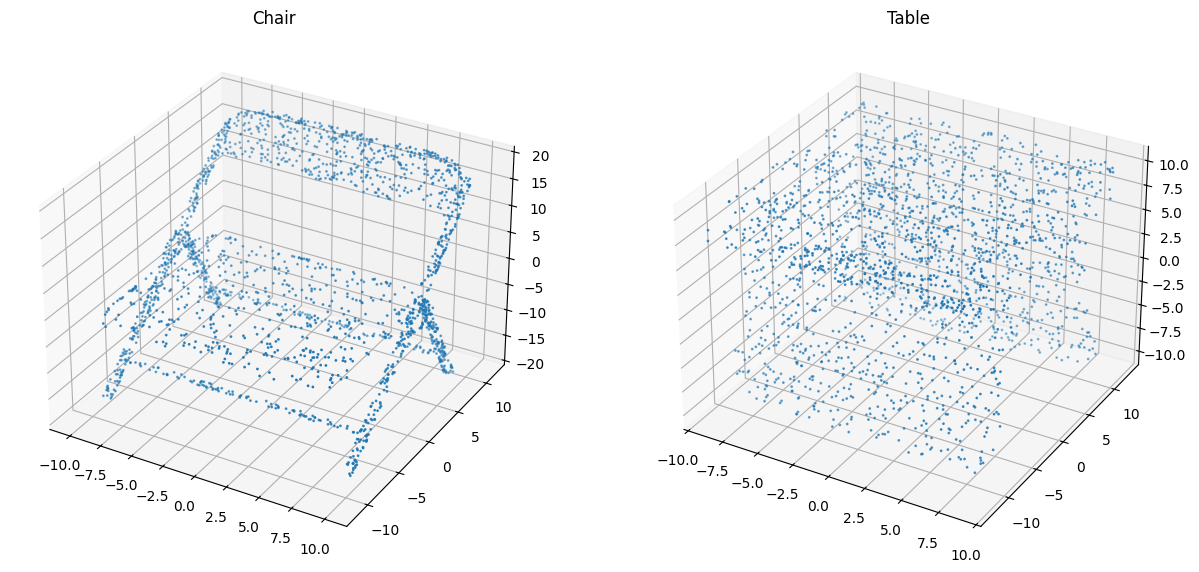

In [ ]:
mesh2 = trimesh.load(os.path.join(Data_Dir, 'table/train/table_0002.off'))
points1 = mesh1.sample(2048)
points2 = mesh2.sample(2048)
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
ax1.scatter(points1[:, 0], points1[:, 1], points1[:, 2], s=1)
ax2.scatter(points2[:, 0], points2[:, 1], points2[:, 2], s=1)
ax1.set_title('Chair')
ax2.set_title('Table')
plt.show()

# Exploratory Data Analysis

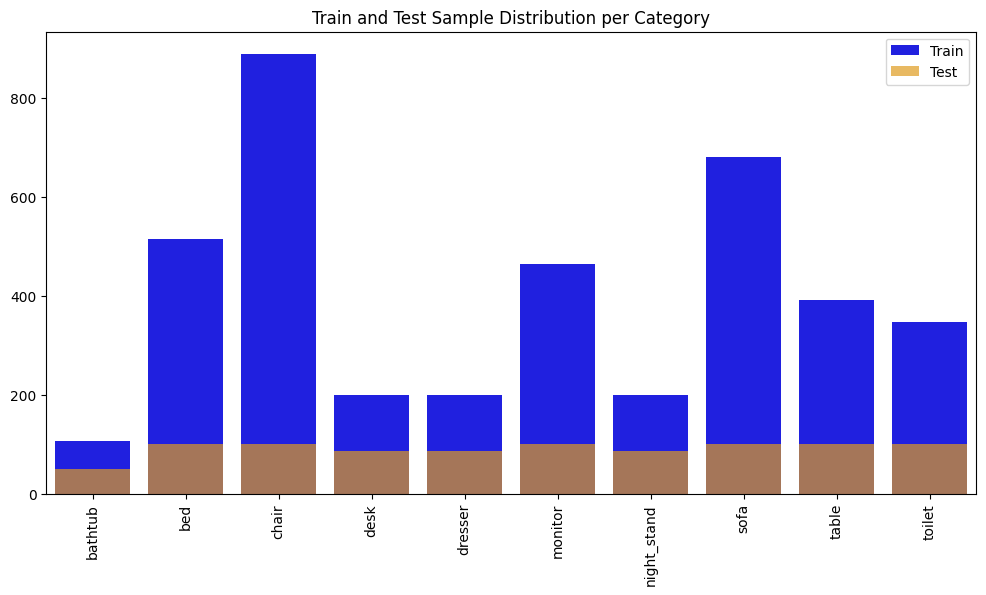

In [ ]:
# Data analysis
categories = sorted(os.listdir(Data_Dir))
label_encoder = LabelEncoder()
label_encoder.fit(categories)
category_counts = {}
for cat in categories:
    train_path = os.path.join(Data_Dir, cat, "train")
    test_path = os.path.join(Data_Dir, cat, "test")
    category_counts[cat] = {
        "train": len(os.listdir(train_path)),
        "test": len(os.listdir(test_path))
    }

train_counts = [category_counts[cat]["train"] for cat in categories]
test_counts = [category_counts[cat]["test"] for cat in categories]

plt.figure(figsize=(12, 6))
sns.barplot(x=categories, y=train_counts, color="blue", label="Train")
sns.barplot(x=categories, y=test_counts, color="orange", label="Test", alpha=0.7)
plt.xticks(rotation=90)
plt.title("Train and Test Sample Distribution per Category")
plt.legend()
plt.show()

# Data Preprocessing

In [ ]:
#Validate off Function
def is_valid_off_file(file_path, num_points=1024):
    try:
        with open(file_path, 'r') as f:
            header = f.readline().strip()
        if header != 'OFF':
            return False

        mesh = o3d.io.read_triangle_mesh(file_path)
        if len(mesh.triangles) == 0:
            return False

        # Try sampling points to confirm mesh integrity
        _ = mesh.sample_points_uniformly(number_of_points=num_points)
        return True
    except:
        return False

# Pre-filter valid files
file_paths = []
labels = []

for cat in tqdm(categories, desc="Filtering valid files"):
    for split in ["train", "test"]:
        folder = os.path.join(Data_Dir, cat, split)
        for file in os.listdir(folder):
            file_path = os.path.join(folder, file)
            if is_valid_off_file(file_path):
                file_paths.append(file_path)
                labels.append(label_encoder.transform([cat])[0])

print(f"Total valid samples after filtering: {len(file_paths)}")

# Train and test Split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

Filtering valid files:   0%|          | 0/10 [00:00<?, ?it/s]

Total valid samples after filtering: 4901


# Dataset Loader and Class

In [ ]:
# Custom Dataset
class PointCloudDataset(Dataset):
    def __init__(self, file_paths, labels, num_points=1024):
        self.file_paths = file_paths
        self.labels = labels
        self.num_points = num_points

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        while True:
            try:
                file_path = self.file_paths[idx]
                with open(file_path, 'r') as f:
                    header = f.readline().strip()
                if header != 'OFF':
                    raise ValueError("Invalid OFF header")

                mesh = o3d.io.read_triangle_mesh(file_path)
                if len(mesh.triangles) == 0:
                    raise ValueError("No triangles in mesh")

                pcd = mesh.sample_points_uniformly(number_of_points=self.num_points)
                points = np.asarray(pcd.points)

                label = self.labels[idx]
                return torch.tensor(points, dtype=torch.float32), torch.tensor(label, dtype=torch.long)
            except:
                # Pick a random index if this file is corrupt
                idx = random.randint(0, len(self.file_paths) - 1)

# Create dataloaders
batch_size = 32
train_dataset = PointCloudDataset(train_paths, train_labels)
val_dataset = PointCloudDataset(val_paths, val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#PointNet model

In [ ]:
# Simple PointNet Model
class SimplePointNet(nn.Module):
    def __init__(self, num_classes):
        super(SimplePointNet, self).__init__()
        self.mlp1 = nn.Linear(3, 64)
        self.mlp2 = nn.Linear(64, 128)
        self.mlp3 = nn.Linear(128, 1024)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.relu(self.mlp1(x))
        x = self.relu(self.mlp2(x))
        x = self.relu(self.mlp3(x))
        x = torch.max(x, dim=1)[0]
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#Training the model

In [ ]:
# Setup Model, Loss, Optimizer
num_classes = len(categories)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimplePointNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0

    for point_clouds, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        point_clouds, labels = point_clouds.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(point_clouds)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    acc = correct / len(train_dataset)
    print(f"Epoch {epoch+1} - Loss: {running_loss:.4f}, Train Accuracy: {acc*100:.2f}%")

Epoch 1:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 1 - Loss: 868.6620, Train Accuracy: 18.62%


Epoch 2:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 2 - Loss: 286.5159, Train Accuracy: 39.21%


Epoch 3:   0%|          | 0/123 [00:00<?, ?it/s]

...

Epoch 8 - Loss: 227.7835, Train Accuracy: 61.10%


Epoch 9:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 9 - Loss: 173.4488, Train Accuracy: 66.73%


Epoch 10:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 10 - Loss: 99.1605, Train Accuracy: 76.68%


In [ ]:
# Validation
model.eval()
correct = 0
with torch.no_grad():
    for point_clouds, labels in val_loader:
        point_clouds, labels = point_clouds.to(device), labels.to(device)
        outputs = model(point_clouds)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
val_acc = correct / len(val_dataset)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Validation Accuracy: 81.35%


#Visualization

In [ ]:
# Visualize
def visualize_point_cloud_matplotlib(points, predicted_label):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, c='b', alpha=0.8)
    ax.set_title(f'Predicted Class: {predicted_label}', fontsize=14)

    # Optional: Adjust axis for better view
    ax.set_axis_off()
    ax.view_init(elev=20, azim=30)

    plt.show()

True: chair, Predicted: chair


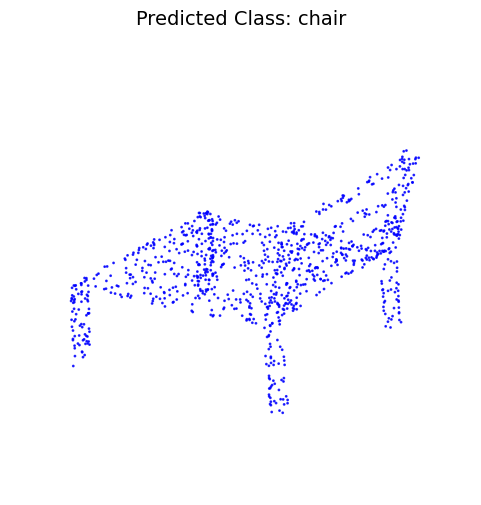

True: bathtub, Predicted: bed


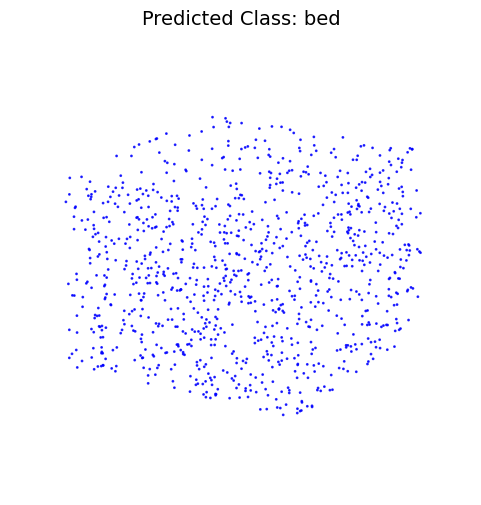

True: toilet, Predicted: monitor


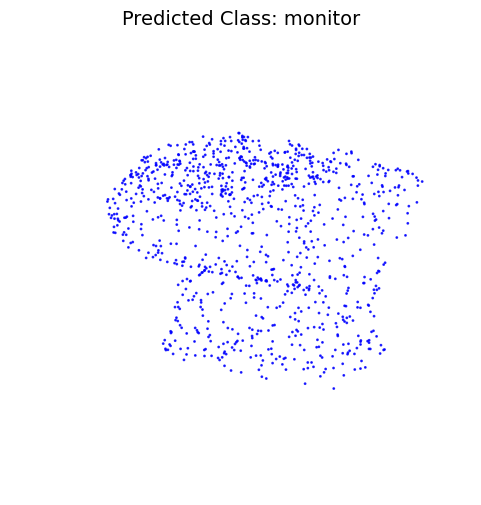

True: chair, Predicted: chair


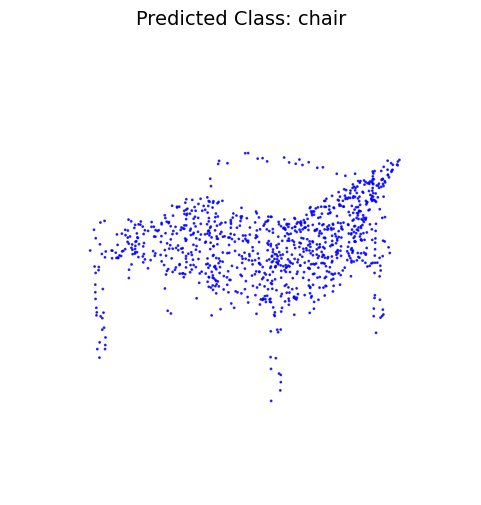

True: bed, Predicted: bed


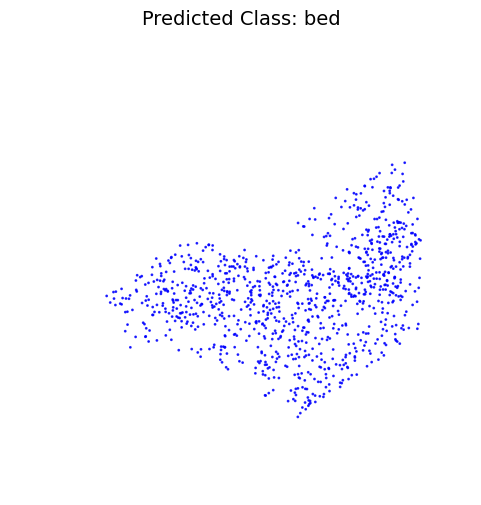

In [ ]:
# Consistent label mapping
idx_to_class = {i: label for i, label in enumerate(label_encoder.classes_)}

model.eval()
with torch.no_grad():
    for i in range(5):
        points, true_label = val_dataset[i]
        input_points = points.unsqueeze(0).to(device)
        outputs = model(input_points)
        pred_label_idx = outputs.argmax(dim=1).item()
        pred_label_name = idx_to_class[pred_label_idx]
        true_label_name = idx_to_class[true_label.item()]

        print(f"True: {true_label_name}, Predicted: {pred_label_name}")
        visualize_point_cloud_matplotlib(points.cpu().numpy(), pred_label_name)